In [48]:
import glob
import pandas as pd
import os

test_files = glob.glob("../power_tests/test*.csv")


def process_test_file(f):
    _, subsample_frac, downsample_frac = os.path.basename(f).replace(".csv","").split("_")
    print(downsample_frac)
    return pd.read_csv(f).assign(downsample_frac=downsample_frac, subsample_frac=subsample_frac)


df = pd.concat(map(process_test_file, test_files)).sort_values(["subsample_frac","downsample_frac"])
df

0.7
0.1
0.2
0.3
0.6
1.0
0.9
0.4
0.2
0.1
0.3
0.5
0.8
0.9
0.1
0.7
0.4
0.5
0.6
1.0
0.8
0.2
0.4
0.7
0.6
0.5
0.3
1.0
0.4
0.9
0.2
0.7
0.6
0.3
0.8
0.5
1.0
0.7
0.1
0.4
0.5
0.6
1.0
0.2
0.4
0.1
0.5
0.3
0.1
0.7
0.2
0.9
0.8
0.3
0.6
1.0
1.0
0.5
0.4
0.1
0.8
0.3
0.6
0.7
0.2
0.9
0.6
0.3
0.8
0.9
0.2
0.7
0.8
0.5
1.0
0.1
0.4
0.9
0.6
0.3
0.8
0.9
0.2
0.7
0.5
1.0
0.8
0.9
0.1
0.4
1.0
0.5
0.8
0.9
0.4
0.1
0.3
0.6
0.7
0.2


,Unnamed: 0,guide,gene,mu,is_target,p_value,downsample_frac,subsample_frac
0,0,KRT18_TSS|1,KRT18,-1.639299,True,4.602312e-03,0.1,0.1
1,1,KRT18_TSS|2,KRT18,-0.739297,True,4.735046e-02,0.1,0.1
0,0,KRT18_TSS|1,KRT18,-0.977074,True,7.754865e-03,0.2,0.1
1,1,KRT18_TSS|2,KRT18,-0.395319,True,9.934459e-02,0.2,0.1
0,0,KRT18_TSS|1,KRT18,-1.070083,True,1.310399e-04,0.3,0.1
...,...,...,...,...,...,...,...,...
1,1,KRT18_TSS|2,KRT18,-1.271027,True,9.234790e-76,0.8,1.0
0,0,KRT18_TSS|1,KRT18,-1.325522,True,2.944668e-79,0.9,1.0
1,1,KRT18_TSS|2,KRT18,-1.217497,True,2.631472e-82,0.9,1.0
0,0,KRT18_TSS|1,KRT18,-1.280721,True,2.211701e-84,1.0,1.0


<Axes: xlabel='downsample_frac', ylabel='subsample_frac'>

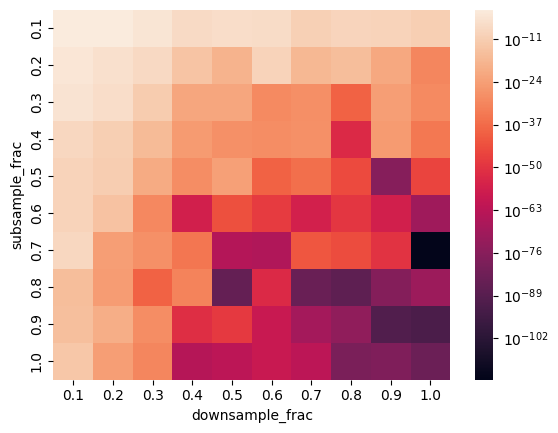

In [49]:
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize


pvals

pvals = df.query("guide=='KRT18_TSS|1'").pivot(
    index=["subsample_frac"], columns = "downsample_frac", values="p_value"
)
sns.heatmap(pvals, norm=LogNorm())
# sns.scatterplot(df, x="subsample_frac", y="downsample_frac", size='mu', hue="p_value", palette="viridis")
